<h2 style="text-align: center">  Displaying Geotagged Photos</h2><br>

1. First import all the libraries
2. open photos from the local drive
3. Extracted LAT LONG from EXIF and convert them to decimal degree
4. create point files, set CRS 
5. convert geodataframe to GeoJSON
6. Design Webpage with HTML and CSS
7. Fetch geoJSON into JS and visualize

In [ ]:
import os
import pandas as pd
# Image EXIF packages
from PIL.ExifTags import TAGS, GPSTAGS 
import PIL.Image
import PIL.ExifTags
import json
from datetime import datetime
import pandas as pd
# Shapefile packages
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [ ]:
#empty list to hold all GPS points

point_list = []
#accessing each file in the directory
for filename in os.listdir('/Users/felcysmac/Documents/MyProject/TheGoodQuest_Project/Photos'):
        filepath = os.path.join('/Users/felcysmac/Documents/MyProject/TheGoodQuest_Project/Photos', filename)
        #including exception handling to avoid errors
        try:
            #read image data
            img = PIL.Image.open(filepath)    
            #extract EXIF data
            exif = {PIL.ExifTags.TAGS[k]: v for k, v in img._getexif().items() if k in PIL.ExifTags.TAGS}
            #point_list.append(exif['GPSInfo'])
            print(exif['GPSInfo'])
            #retrieve date and time
            date=exif['DateTime'].split(' ')[0]
            time=exif['DateTime'].split(' ')[1]
            #extracting latitude and longitude from the EXIF dictionary

            LatLong = [exif['GPSInfo'][2], exif['GPSInfo'][4]]
            altitude = exif['GPSInfo'][6]
            #conversion to decimal degrees
            Lat_deci = LatLong[0][0]+LatLong[0][1]/60.0+LatLong[0][2]/3600          
            Long_deci = LatLong[1][0]+LatLong[1][1]/60.0+LatLong[1][2]/3600
            #readable GPS location format
            GPSLocation = f"{LatLong[0][0]}°{LatLong[0][1]}' {LatLong[0][2]}\" N, " \
                          f"{LatLong[1][0]}°{LatLong[1][1]}' {LatLong[1][2]}\" E"
            Latitude = f"{LatLong[0][0]}°{LatLong[0][1]}' {LatLong[0][2]}\" N, "
            Longitude = f"{LatLong[1][0]}°{LatLong[1][1]}' {LatLong[1][2]}\" E"
            #append data to point list with required fields
            point_list.append({'Photo_no':filename, 
                               'GPSLocation':GPSLocation, 
                               'Latitude':Latitude, 'Longitude':Longitude,
                                'Lat_deci':Lat_deci, 'Long_deci':Long_deci,
                                'Altitude':f"{float(exif['GPSInfo'][6]):.2f}",
                                'Date':date, 'Time':time})
            print(point_list) 


            # Do something with img
        except Exception as e:
            print(f"✗ Error with {filename}: {e}")

✗ Error with IMG_10.png: 'GPSInfo'
{0: b'\x02\x02\x00\x00', 1: 'N', 2: (12.0, 13.0, 14.6), 3: 'E', 4: (76.0, 1.0, 17.43), 5: b'\x00', 6: 848.012853470437, 12: 'K', 13: 0.2621031701704609, 16: 'M', 17: 149.15191637630662, 23: 'M', 24: 149.15191637630662, 31: 12.213381294964028}
[{'Photo_no': 'IMG_1.png', 'GPSLocation': '12.0°13.0\' 14.6" N, 76.0°1.0\' 17.43" E', 'Latitude': '12.0°13.0\' 14.6" N, ', 'Longitude': '76.0°1.0\' 17.43" E', 'Lat_deci': 12.220722222222223, 'Long_deci': 76.02150833333333, 'Altitude': '848.01', 'Date': '2020:06:13', 'Time': '13:46:40'}]
{0: b'\x02\x02\x00\x00', 1: 'N', 2: (12.0, 2.0, 37.25), 3: 'E', 4: (77.0, 36.0, 36.8), 5: b'\x00', 6: 893.8503727369542, 12: 'K', 13: 0.04912749307402788, 16: 'M', 17: 357.42990110529377, 23: 'M', 24: 357.42990110529377, 29: '2020:09:19', 31: 8.006708760852407}
[{'Photo_no': 'IMG_1.png', 'GPSLocation': '12.0°13.0\' 14.6" N, 76.0°1.0\' 17.43" E', 'Latitude': '12.0°13.0\' 14.6" N, ', 'Longitude': '76.0°1.0\' 17.43" E', 'Lat_deci': 1

In [13]:
point_list
# _df = pd.DataFrame(point_list)
# point_list_df.head()

[{'Photo_no': 'IMG_1.png',
  'GPSLocation': '12.0°13.0\' 14.6" N, 76.0°1.0\' 17.43" E',
  'Latitude': '12.0°13.0\' 14.6" N, ',
  'Longitude': '76.0°1.0\' 17.43" E',
  'Lat_deci': 12.220722222222223,
  'Long_deci': 76.02150833333333,
  'Altitude': '848.01',
  'Date': '2020:06:13',
  'Time': '13:46:40'},
 {'Photo_no': 'IMG_9390.png',
  'GPSLocation': '12.0°2.0\' 37.25" N, 77.0°36.0\' 36.8" E',
  'Latitude': '12.0°2.0\' 37.25" N, ',
  'Longitude': '77.0°36.0\' 36.8" E',
  'Lat_deci': 12.043680555555556,
  'Long_deci': 77.61022222222222,
  'Altitude': '893.85',
  'Date': '2020:09:19',
  'Time': '15:57:05'},
 {'Photo_no': 'IMG_9347.png',
  'GPSLocation': '12.0°15.0\' 24.88" N, 77.0°9.0\' 48.13" E',
  'Latitude': '12.0°15.0\' 24.88" N, ',
  'Longitude': '77.0°9.0\' 48.13" E',
  'Lat_deci': 12.256911111111112,
  'Long_deci': 77.16336944444446,
  'Altitude': '635.79',
  'Date': '2020:09:19',
  'Time': '08:47:25'},
 {'Photo_no': 'IMG_11.png',
  'GPSLocation': '11.0°59.0\' 7.27" N, 76.0°3.0\' 53

In [14]:
# 2. convert point list to pandas dataframe
df = pd.DataFrame(point_list)
print("Pandas DataFrame:")
print(df.head())

Pandas DataFrame:
       Photo_no                               GPSLocation  \
0     IMG_1.png    12.0°13.0' 14.6" N, 76.0°1.0' 17.43" E   
1  IMG_9390.png    12.0°2.0' 37.25" N, 77.0°36.0' 36.8" E   
2  IMG_9347.png   12.0°15.0' 24.88" N, 77.0°9.0' 48.13" E   
3    IMG_11.png    11.0°59.0' 7.27" N, 76.0°3.0' 53.02" E   
4    IMG_13.png  11.0°57.0' 11.46" N, 76.0°14.0' 53.27" E   

                Latitude            Longitude   Lat_deci  Long_deci Altitude  \
0   12.0°13.0' 14.6" N,    76.0°1.0' 17.43" E  12.220722  76.021508   848.01   
1   12.0°2.0' 37.25" N,    77.0°36.0' 36.8" E  12.043681  77.610222   893.85   
2  12.0°15.0' 24.88" N,    77.0°9.0' 48.13" E  12.256911  77.163369   635.79   
3   11.0°59.0' 7.27" N,    76.0°3.0' 53.02" E  11.985353  76.064728   868.12   
4  11.0°57.0' 11.46" N,   76.0°14.0' 53.27" E  11.953183  76.248131   733.43   

         Date      Time  
0  2020:06:13  13:46:40  
1  2020:09:19  15:57:05  
2  2020:09:19  08:47:25  
3  2020:06:13  18:40:49  
4  2

In [15]:
# 3. Convert the DataFrame to a GeoDataFrame
# The points_from_xy function creates shapely Point objects from longitude and latitude columns
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.Long_deci, df.Lat_deci),
    crs="EPSG:4326" # Set the Coordinate Reference System to WGS84 (standard lat/lon)
)
print("\nGeoDataFrame:")
print(gdf.head())
print(f"CRS: {gdf.crs}")



GeoDataFrame:
       Photo_no                               GPSLocation  \
0     IMG_1.png    12.0°13.0' 14.6" N, 76.0°1.0' 17.43" E   
1  IMG_9390.png    12.0°2.0' 37.25" N, 77.0°36.0' 36.8" E   
2  IMG_9347.png   12.0°15.0' 24.88" N, 77.0°9.0' 48.13" E   
3    IMG_11.png    11.0°59.0' 7.27" N, 76.0°3.0' 53.02" E   
4    IMG_13.png  11.0°57.0' 11.46" N, 76.0°14.0' 53.27" E   

                Latitude            Longitude   Lat_deci  Long_deci Altitude  \
0   12.0°13.0' 14.6" N,    76.0°1.0' 17.43" E  12.220722  76.021508   848.01   
1   12.0°2.0' 37.25" N,    77.0°36.0' 36.8" E  12.043681  77.610222   893.85   
2  12.0°15.0' 24.88" N,    77.0°9.0' 48.13" E  12.256911  77.163369   635.79   
3   11.0°59.0' 7.27" N,    76.0°3.0' 53.02" E  11.985353  76.064728   868.12   
4  11.0°57.0' 11.46" N,   76.0°14.0' 53.27" E  11.953183  76.248131   733.43   

         Date      Time                   geometry  
0  2020:06:13  13:46:40  POINT (76.02151 12.22072)  
1  2020:09:19  15:57:05  POINT 

/var/folders/6m/dfkpy_9n7q73tdzs5yvdgtpr0000gn/T/ipykernel_34304/3806182163.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


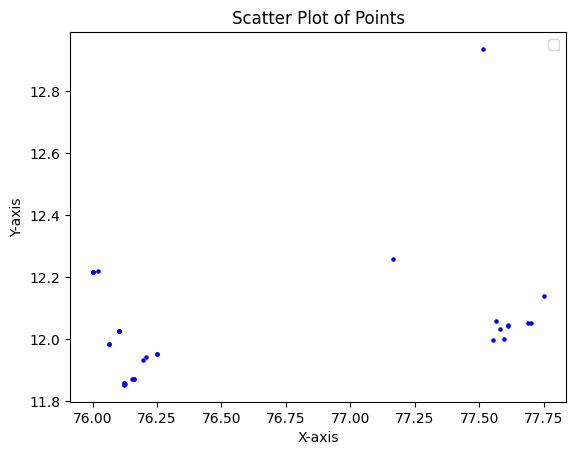

In [16]:
# 4. Plot the GeoDataFrame
plt.figure(figsize=(10, 6))
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Scatter Plot of Points")
plt.legend()
    #plt.grid(True)
plt.scatter(gdf.Long_deci, gdf.Lat_deci, 
            marker='o', color='blue', s=5, label='Data Points', )

plt.show()

In [ ]:
#dropping unused columns
gdf.drop(columns=['Lat_deci', 'Long_deci'], inplace=True)

In [18]:
#final GeoDataFrame
gdf.head()
# 5. Export to GeoJSON
output_geojson = "output_locations.geojson"
gdf.to_file(output_geojson, driver="GeoJSON")
print(f"Successfully saved to {output_geojson}")

,Photo_no,GPSLocation,Latitude,Longitude,Altitude,Date,Time,geometry
0,IMG_1.png,"12.0°13.0' 14.6"" N, 76.0°1.0' 17.43"" E","12.0°13.0' 14.6"" N,","76.0°1.0' 17.43"" E",848.01,2020:06:13,13:46:40,POINT (76.02151 12.22072)
1,IMG_9390.png,"12.0°2.0' 37.25"" N, 77.0°36.0' 36.8"" E","12.0°2.0' 37.25"" N,","77.0°36.0' 36.8"" E",893.85,2020:09:19,15:57:05,POINT (77.61022 12.04368)
2,IMG_9347.png,"12.0°15.0' 24.88"" N, 77.0°9.0' 48.13"" E","12.0°15.0' 24.88"" N,","77.0°9.0' 48.13"" E",635.79,2020:09:19,08:47:25,POINT (77.16337 12.25691)
3,IMG_11.png,"11.0°59.0' 7.27"" N, 76.0°3.0' 53.02"" E","11.0°59.0' 7.27"" N,","76.0°3.0' 53.02"" E",868.12,2020:06:13,18:40:49,POINT (76.06473 11.98535)
4,IMG_13.png,"11.0°57.0' 11.46"" N, 76.0°14.0' 53.27"" E","11.0°57.0' 11.46"" N,","76.0°14.0' 53.27"" E",733.43,2020:06:14,12:30:02,POINT (76.24813 11.95318)


In [19]:
# 4. Export to a Shapefile
# output_shapefile = "output_locations.shp"
# gdf.to_file(output_shapefile, driver="ESRI Shapefile")
# print(f"\nSuccessfully saved to {output_shapefile}")



Successfully saved to output_locations.geojson


<h2 style="text-align:center;">SUCCESSFUL END OF CODES </h2>